# Ocean and sea-ice drift — Full-CPL spin-up + piControl

Figures:
* `Full-CPL_OCN_all_annual_0-2500.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [2]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os, re, glob, warnings, string
import numpy as np
import xarray as xr
import cftime
import contextlib

from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, FixedLocator
import pandas as pd 
try:
    from cftime import num2date
except Exception:
    num2date = None

from util.ctrl_plotting import OceanDriftPlotter
from util.ctrl_processing import AMOCDiagnosticsBuilder, MPASDiagnosticsBuilder, SSHBuilder, SSSBuilder, SSTBuilder, SeaIceBuilder
from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish

## Setup

In [3]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ocn_ts"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ocn_ts"                # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPERIMENT     = "Full-CPL"    # experiment analysed (spin-up followed by its piControl)
CTRL_YEARS     = (0, 2500)     # combined spin-up + piControl model years (axes, cache/figure names)
SPINUP_MARKERS = (350, 2000)   # vertical markers; trends fit from the first, decay fit up to the second


In [4]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts


## 1 SST
### Settings

In [5]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# === Config ===
subdir           = "post/time_series"
# 'var_name' is a label for filenames; the actual NetCDF var is 'mpas_var'
var_name         = "SST"
mpas_var         = "timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature"
file_stem        = "mpasTimeSeriesOcean"   # <— matches builder arg
file_suffix      = ".nc"                 # keep default
region           = "global"
level_index      = 0 # first layer (surface)

stamp_regex      = None
xr_engine        = "netcdf4"              # often faster for many small MPAS files
suffix           = "annual"
spinup_period    = list(CTRL_YEARS)               # naming only
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = True

print(f"[INFO] Experiment: {experiment}")
print(f"[INFO] Spin-up:    {spinup_name}")
print(f"[INFO] piControl:  {picontrol_name}")
print(f"[INFO] MPAS var:   {mpas_var}")


[INFO] Experiment: Full-CPL
[INFO] Spin-up:    20231209.v3.LR.piControl-spinup.chrysalis
[INFO] piControl:  v3.LR.piControl
[INFO] MPAS var:   timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature


### Compute & plot

In [6]:
# === 1) Build per-source annual NetCDFs (cached) ===
builder = SSTBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,         # <— renamed from moc_file_pattern
    file_suffix=file_suffix,     # keep default
    stamp_regex=stamp_regex,     # <-- important: no yyyymm-yyyymm stamps
    xr_engine=xr_engine,
    var_name=mpas_var,           # <— actual NetCDF variable to read
    force_reprocess=force_reprocess,
    region=region,   # Global Ocean
    level_index=level_index,    # first layer (surface)
)

paths = builder.build_sources(
    out_dir=out_dir,
    var_name=var_name,           # <— label for filenames only
    suffix=suffix
)
spinup_annual_nc = paths["spinup"]
pctl_annual_nc   = paths["piControl"]
print(f"[OK] Spin-up annual:  {spinup_annual_nc}")
print(f"[OK] piControl annual: {pctl_annual_nc}")

# === 2) Build combined tidy diagnostics (spin-up + piControl) — DATA ONLY
# Include the true MPAS variable in the filename to avoid collisions
combined_tidy = os.path.join(
    out_dir,
    f"{var_name}_{experiment}_combined_{mpas_var}_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
)

combined_tidy = builder.build_combined_tidy(
    spinup_nc=spinup_annual_nc,
    pctl_nc=pctl_annual_nc,
    combined_tidy_nc=combined_tidy,
    filter_window=filter_window,
    trend_windows=trend_windows,
    add_per_decade=add_per_decade,
    sequence=sequence,
    force=False,                 # set True to bypass freshness check
    strict=True,
)
print("[OK] Wrote combined tidy diagnostics:", combined_tidy)

# === 3) Quick sanity summary (no plotting) ===
try:
    ds = xr.open_dataset(combined_tidy)
    data_var = mpas_var if mpas_var in ds.data_vars else (var_name if var_name in ds.data_vars else None)
    if data_var is None:
        raise KeyError(f"Could not find '{mpas_var}' or '{var_name}' in {combined_tidy}. Found: {list(ds.data_vars)}")

    years = (ds["year"].values if "year" in ds.coords else ds["time"].dt.year.values)
    vals  = ds[data_var].values
    print(f"[SUMMARY] {data_var}: years {int(np.nanmin(years))}–{int(np.nanmax(years))} "
          f"(N={len(years)}). NaNs={int(np.isnan(vals).sum())}")

    for k in ("filtered_11yr", "sliding_trend_10yr", "sliding_trend_10yr_per_decade",
              "sliding_trend_30yr", "sliding_trend_30yr_per_decade"):
        if k in ds:
            v = ds[k].values
            print(f"[SUMMARY] {k}: shape={v.shape}, NaNs={int(np.isnan(v).sum())}")
    ds.close()
except Exception as e:
    print(f"[WARN] Could not open summary: {e}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


('nOceanRegions', 'nOceanRegionsTmp', 'nRegions', 'region', 'oceanRegions')
('Time', 'nOceanRegions')
('nOceanRegions', 'nOceanRegionsTmp', 'nRegions', 'region', 'oceanRegions')
('Time', 'nOceanRegions')
[OK] Spin-up annual:  /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/20231209.v3.LR.piControl-spinup.chrysalis_SST_timeseries_annual.nc
[OK] piControl annual: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/v3.LR.piControl_SST_timeseries_annual.nc
[OK] Wrote combined tidy diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/SST_Full-CPL_combined_timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature_annual_0-2500.nc
[SUMMARY] timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature: years 1–2500 (N=2500). NaNs=0
[SUMMARY] filtered_11yr: shape=(2500,), NaNs=10
[SUMMARY] sliding_trend_10yr: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_10yr_per_

## 2 SSS
### Settings

In [7]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# === Config ===
subdir           = "post/time_series"
# 'var_name' is a label for filenames; the actual NetCDF var is 'mpas_var'
var_name         = "SSS"
mpas_var         = "timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerSalinity"
file_stem        = "mpasTimeSeriesOcean"   # <— matches builder arg
file_suffix      = ".nc"                 # keep default
region           = "global"
level_index      = 0 # first layer (surface)

stamp_regex      = None
xr_engine        = "netcdf4"              # often faster for many small MPAS files
suffix           = "annual"
spinup_period    = list(CTRL_YEARS)               # naming only
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = True

print(f"[INFO] Experiment: {experiment}")
print(f"[INFO] Spin-up:    {spinup_name}")
print(f"[INFO] piControl:  {picontrol_name}")
print(f"[INFO] MPAS var:   {mpas_var}")


[INFO] Experiment: Full-CPL
[INFO] Spin-up:    20231209.v3.LR.piControl-spinup.chrysalis
[INFO] piControl:  v3.LR.piControl
[INFO] MPAS var:   timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerSalinity


### Compute & plot

In [8]:
# === 1) Build per-source annual NetCDFs (cached) ===
builder = SSSBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,         # <— renamed from moc_file_pattern
    file_suffix=file_suffix,     # keep default
    stamp_regex=stamp_regex,     # <-- important: no yyyymm-yyyymm stamps
    xr_engine=xr_engine,
    var_name=mpas_var,           # <— actual NetCDF variable to read
    force_reprocess=force_reprocess,
    region=region,   # Global Ocean
    level_index=level_index,    # first layer (surface)
)

paths = builder.build_sources(
    out_dir=out_dir,
    var_name=var_name,           # <— label for filenames only
    suffix=suffix
)
spinup_annual_nc = paths["spinup"]
pctl_annual_nc   = paths["piControl"]
print(f"[OK] Spin-up annual:  {spinup_annual_nc}")
print(f"[OK] piControl annual: {pctl_annual_nc}")

# === 2) Build combined tidy diagnostics (spin-up + piControl) — DATA ONLY
# Include the true MPAS variable in the filename to avoid collisions
combined_tidy = os.path.join(
    out_dir,
    f"{var_name}_{experiment}_combined_{mpas_var}_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
)

combined_tidy = builder.build_combined_tidy(
    spinup_nc=spinup_annual_nc,
    pctl_nc=pctl_annual_nc,
    combined_tidy_nc=combined_tidy,
    filter_window=filter_window,
    trend_windows=trend_windows,
    add_per_decade=add_per_decade,
    sequence=sequence,
    force=False,                 # set True to bypass freshness check
    strict=True,
)
print("[OK] Wrote combined tidy diagnostics:", combined_tidy)

# === 3) Quick sanity summary (no plotting) ===
try:
    ds = xr.open_dataset(combined_tidy)
    data_var = mpas_var if mpas_var in ds.data_vars else (var_name if var_name in ds.data_vars else None)
    if data_var is None:
        raise KeyError(f"Could not find '{mpas_var}' or '{var_name}' in {combined_tidy}. Found: {list(ds.data_vars)}")

    years = (ds["year"].values if "year" in ds.coords else ds["time"].dt.year.values)
    vals  = ds[data_var].values
    print(f"[SUMMARY] {data_var}: years {int(np.nanmin(years))}–{int(np.nanmax(years))} "
          f"(N={len(years)}). NaNs={int(np.isnan(vals).sum())}")

    for k in ("filtered_11yr", "sliding_trend_10yr", "sliding_trend_10yr_per_decade",
              "sliding_trend_30yr", "sliding_trend_30yr_per_decade"):
        if k in ds:
            v = ds[k].values
            print(f"[SUMMARY] {k}: shape={v.shape}, NaNs={int(np.isnan(v).sum())}")
    ds.close()
except Exception as e:
    print(f"[WARN] Could not open summary: {e}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


('nOceanRegions', 'nOceanRegionsTmp', 'nRegions', 'region', 'oceanRegions')
('Time', 'nOceanRegionsTmp', 'nVertLevels')
('nOceanRegions', 'nOceanRegionsTmp', 'nRegions', 'region', 'oceanRegions')
('Time', 'nOceanRegionsTmp', 'nVertLevels')
[OK] Spin-up annual:  /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/20231209.v3.LR.piControl-spinup.chrysalis_SSS_timeseries_annual.nc
[OK] piControl annual: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/v3.LR.piControl_SSS_timeseries_annual.nc
[OK] Wrote combined tidy diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/SSS_Full-CPL_combined_timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerSalinity_annual_0-2500.nc
[SUMMARY] timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerSalinity: years 1–2500 (N=2500). NaNs=0
[SUMMARY] filtered_11yr: shape=(2500,), NaNs=10
[SUMMARY] sliding_trend_10yr: shape=(2500,), NaNs

## 3 SSH
### Settings

In [9]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# === Config ===
subdir           = "post/time_series"
# 'var_name' is a label for filenames; the actual NetCDF var is 'mpas_var'
var_name         = "SSH"
mpas_var         = "SSH"
file_stem        = "mpasTimeSeriesOcean"   # <— matches builder arg
file_suffix      = ".nc"                 # keep default
stamp_regex      = None
xr_engine        = "netcdf4"              # often faster for many small MPAS files
suffix           = "annual"
spinup_period    = list(CTRL_YEARS)               # naming only
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = False

print(f"[INFO] Experiment: {experiment}")
print(f"[INFO] Spin-up:    {spinup_name}")
print(f"[INFO] piControl:  {picontrol_name}")
print(f"[INFO] MPAS var:   {mpas_var}")


[INFO] Experiment: Full-CPL
[INFO] Spin-up:    20231209.v3.LR.piControl-spinup.chrysalis
[INFO] piControl:  v3.LR.piControl
[INFO] MPAS var:   SSH


### Compute & plot

In [10]:
# === 1) Build per-source annual NetCDFs (cached) ===
builder = SSHBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,         # <— renamed from moc_file_pattern
    xr_engine=xr_engine,
    var_name=mpas_var,           # <— actual NetCDF variable to read
    force_reprocess=force_reprocess,
)

builder = SSHBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,              # the base name
    file_suffix=file_suffix,          # keep default
    stamp_regex=None,                 # <-- important: no yyyymm-yyyymm stamps
    xr_engine=xr_engine,              # "netcdf4" is fine for a single big file
    var_name=mpas_var,
    force_reprocess=force_reprocess,
)

paths = builder.build_sources(
    out_dir=out_dir,
    var_name=var_name,           # <— label for filenames only
    suffix=suffix
)
spinup_annual_nc = paths["spinup"]
pctl_annual_nc   = paths["piControl"]
print(f"[OK] Spin-up annual:  {spinup_annual_nc}")
print(f"[OK] piControl annual: {pctl_annual_nc}")

# === 2) Build combined tidy diagnostics (spin-up + piControl) — DATA ONLY
# Include the true MPAS variable in the filename to avoid collisions
combined_tidy = os.path.join(
    out_dir,
    f"{var_name}_{experiment}_combined_{mpas_var}_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
)

combined_tidy = builder.build_combined_tidy(
    spinup_nc=spinup_annual_nc,
    pctl_nc=pctl_annual_nc,
    combined_tidy_nc=combined_tidy,
    filter_window=filter_window,
    trend_windows=trend_windows,
    add_per_decade=add_per_decade,
    sequence=sequence,
    force=False,                 # set True to bypass freshness check
    strict=True,
)
print("[OK] Wrote combined tidy diagnostics:", combined_tidy)

# === 3) Quick sanity summary (no plotting) ===
try:
    ds = xr.open_dataset(combined_tidy)
    data_var = mpas_var if mpas_var in ds.data_vars else (var_name if var_name in ds.data_vars else None)
    if data_var is None:
        raise KeyError(f"Could not find '{mpas_var}' or '{var_name}' in {combined_tidy}. Found: {list(ds.data_vars)}")

    years = (ds["year"].values if "year" in ds.coords else ds["time"].dt.year.values)
    vals  = ds[data_var].values
    print(f"[SUMMARY] {data_var}: years {int(np.nanmin(years))}–{int(np.nanmax(years))} "
          f"(N={len(years)}). NaNs={int(np.isnan(vals).sum())}")

    for k in ("filtered_11yr", "sliding_trend_10yr", "sliding_trend_10yr_per_decade",
              "sliding_trend_30yr", "sliding_trend_30yr_per_decade"):
        if k in ds:
            v = ds[k].values
            print(f"[SUMMARY] {k}: shape={v.shape}, NaNs={int(np.isnan(v).sum())}")
    ds.close()
except Exception as e:
    print(f"[WARN] Could not open summary: {e}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[OK] Spin-up annual:  /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/20231209.v3.LR.piControl-spinup.chrysalis_SSH_timeseries_annual.nc
[OK] piControl annual: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/v3.LR.piControl_SSH_timeseries_annual.nc
[OK] Wrote combined tidy diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/SSH_Full-CPL_combined_SSH_annual_0-2500.nc
[SUMMARY] SSH: years 1–2500 (N=2500). NaNs=0
[SUMMARY] filtered_11yr: shape=(2500,), NaNs=10
[SUMMARY] sliding_trend_10yr: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_10yr_per_decade: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_30yr: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_30yr_per_decade: shape=(2500,), NaNs=0
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts


## 4 AMOC
### Settings

In [11]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# === Config ===
subdir           = "post/time_series/moc"
# 'var_name' is just a label for file naming; the actual NetCDF variable is 'amoc_var'
var_name         = "AMOC"
amoc_var         = "mocAtlantic26"
moc_file_pattern = r"mocTimeSeries_(\d{6})-(\d{6})\.nc$"
xr_engine        = "netcdf4"   # consider "h5netcdf" for many small files
suffix           = "annual"
spinup_period    = list(CTRL_YEARS)   # used here only for naming
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = False

print(f"[INFO] Experiment: {experiment}")
print(f"[INFO] Spin-up:    {spinup_name}")
print(f"[INFO] piControl:  {picontrol_name}")
print(f"[INFO] AMOC var:   {amoc_var}")


[INFO] Experiment: Full-CPL
[INFO] Spin-up:    20231209.v3.LR.piControl-spinup.chrysalis
[INFO] piControl:  v3.LR.piControl
[INFO] AMOC var:   mocAtlantic26


### Compute & plot

In [12]:
# === 1) Build per-source annual NetCDFs (cached) ===
builder = AMOCDiagnosticsBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    moc_file_pattern=moc_file_pattern,
    xr_engine=xr_engine,
    var_name=amoc_var,   # <- this is the actual NetCDF variable to read
    force_reprocess = force_reprocess, 
)
paths = builder.build_sources(out_dir=out_dir, suffix=suffix)
spinup_annual_nc = paths["spinup"]
pctl_annual_nc   = paths["piControl"]
print(f"[OK] Spin-up annual:  {spinup_annual_nc}")
print(f"[OK] piControl annual: {pctl_annual_nc}")

# Build combined tidy diagnostics (spin-up + piControl) — DATA ONLY ===
# Safer, informative output filename
combined_tidy = os.path.join(
    out_dir,
    f"{var_name}_{experiment}_combined_{amoc_var}_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
)
# Force append behavior
combined_tidy = builder.build_combined_tidy(
    spinup_nc=spinup_annual_nc,
    pctl_nc=pctl_annual_nc,
    combined_tidy_nc=combined_tidy,
    filter_window=filter_window,
    trend_windows=trend_windows,
    add_per_decade=add_per_decade,
    sequence=sequence,   # <- key
)
print("[OK] Wrote combined tidy diagnostics:", combined_tidy)

# --- Quick sanity summary (no plotting) ---
try:
    ds = xr.open_dataset(combined_tidy)
    years = ds["year"].values
    vals  = ds[amoc_var].values
    print(f"[SUMMARY] {amoc_var}: years {int(years.min())}–{int(years.max())} "
          f"(N={len(years)}). NaNs={int(np.isnan(vals).sum())}")
    ds.close()
except Exception as e:
    print(f"[WARN] Could not open summary: {e}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[OK] Spin-up annual:  /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/20231209.v3.LR.piControl-spinup.chrysalis_amoc_timeseries_annual.nc
[OK] piControl annual: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/v3.LR.piControl_amoc_timeseries_annual.nc
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/20231209.v3.LR.piControl-spinup.chrysalis_amoc_timeseries_annual.nc
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/v3.LR.piControl_amoc_timeseries_annual.nc
[OK] Wrote combined tidy diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/AMOC_Full-CPL_combined_mocAtlantic26_annual_0-2500.nc
[SUMMARY] mocAtlantic26: years 1–2500 (N=2500). NaNs=0
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts


## 5.1 Sea-ice volume, NH
### Settings

In [13]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# === Config ===
subdir           = "post/time_series"
tunit            = ""
var_name         = "iceVolumeNH"
var_unit         = r"x10$^3$km$^3$"
var_fact         = 1e-12 # convert unit to 1e3 km^3 
mpas_var         = "iceVolume"
file_stem        = "seaIceAreaVolNH"     # <— matches builder arg
file_suffix      = ".nc"                 # keep default
stamp_regex      = None
xr_engine        = "netcdf4"              # often faster for many small MPAS files
suffix           = "annual"
spinup_period    = list(CTRL_YEARS)               # naming only
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = False

print(f"[INFO] Experiment: {experiment}")
print(f"[INFO] Spin-up:    {spinup_name}")
print(f"[INFO] piControl:  {picontrol_name}")
print(f"[INFO] MPAS var:   {mpas_var}")


[INFO] Experiment: Full-CPL
[INFO] Spin-up:    20231209.v3.LR.piControl-spinup.chrysalis
[INFO] piControl:  v3.LR.piControl
[INFO] MPAS var:   iceVolume


### Compute & plot

In [14]:
# === 1) Build per-source annual NetCDFs (cached) ===
builder = SeaIceBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,         # <— renamed from moc_file_pattern
    xr_engine=xr_engine,
    var_name=mpas_var,           # <— actual NetCDF variable to read
    force_reprocess=force_reprocess,
)

builder = SeaIceBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,              # the base name
    file_suffix=file_suffix,          # keep default
    stamp_regex=None,                 # <-- important: no yyyymm-yyyymm stamps
    xr_engine=xr_engine,              # "netcdf4" is fine for a single big file
    var_name=mpas_var,
    var_unit=var_unit,
    var_fact=var_fact,
    force_reprocess=force_reprocess,
)

paths = builder.build_sources(
    out_dir=out_dir,
    var_name=var_name,           # <— label for filenames only
    suffix=suffix
)
spinup_annual_nc = paths["spinup"]
pctl_annual_nc   = paths["piControl"]
print(f"[OK] Spin-up annual:  {spinup_annual_nc}")
print(f"[OK] piControl annual: {pctl_annual_nc}")

# === 2) Build combined tidy diagnostics (spin-up + piControl) — DATA ONLY
# Include the true MPAS variable in the filename to avoid collisions
combined_tidy = os.path.join(
    out_dir,
    f"{var_name}_{experiment}_combined_{mpas_var}_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
)

combined_tidy = builder.build_combined_tidy(
    spinup_nc=spinup_annual_nc,
    pctl_nc=pctl_annual_nc,
    combined_tidy_nc=combined_tidy,
    filter_window=filter_window,
    trend_windows=trend_windows,
    add_per_decade=add_per_decade,
    sequence=sequence,
    force=False,                 # set True to bypass freshness check
    strict=True,
)
print("[OK] Wrote combined tidy diagnostics:", combined_tidy)

# === 3) Quick sanity summary (no plotting) ===
try:
    ds = xr.open_dataset(combined_tidy)
    data_var = mpas_var if mpas_var in ds.data_vars else (var_name if var_name in ds.data_vars else None)
    if data_var is None:
        raise KeyError(f"Could not find '{mpas_var}' or '{var_name}' in {combined_tidy}. Found: {list(ds.data_vars)}")

    years = (ds["year"].values if "year" in ds.coords else ds["time"].dt.year.values)
    vals  = ds[data_var].values
    print(f"[SUMMARY] {data_var}: years {int(np.nanmin(years))}–{int(np.nanmax(years))} "
          f"(N={len(years)}). NaNs={int(np.isnan(vals).sum())}")

    for k in ("filtered_11yr", "sliding_trend_10yr", "sliding_trend_10yr_per_decade",
              "sliding_trend_30yr", "sliding_trend_30yr_per_decade"):
        if k in ds:
            v = ds[k].values
            print(f"[SUMMARY] {k}: shape={v.shape}, NaNs={int(np.isnan(v).sum())}")
    ds.close()
except Exception as e:
    print(f"[WARN] Could not open summary: {e}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[OK] Spin-up annual:  /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/20231209.v3.LR.piControl-spinup.chrysalis_iceVolumeNH_timeseries_annual.nc
[OK] piControl annual: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/v3.LR.piControl_iceVolumeNH_timeseries_annual.nc
[OK] Wrote combined tidy diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/iceVolumeNH_Full-CPL_combined_iceVolume_annual_0-2500.nc
[SUMMARY] iceVolume: years 1–2500 (N=2500). NaNs=0
[SUMMARY] filtered_11yr: shape=(2500,), NaNs=10
[SUMMARY] sliding_trend_10yr: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_10yr_per_decade: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_30yr: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_30yr_per_decade: shape=(2500,), NaNs=0
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts


## 5.2 Sea-ice volume, SH
### Settings

In [15]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

# === Select experiment ===
experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined. Please define it before running.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not found in run_dict.")

spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# === Config ===
subdir           = "post/time_series"
tunit            = ""
var_name         = "iceVolumeSH"
var_unit         = r"x10$^3$km$^3$"
var_fact         = 1e-12 # convert unit to 1e3 km^3 
mpas_var         = "iceVolume"
file_stem        = "seaIceAreaVolSH"     # <— matches builder arg
file_suffix      = ".nc"                 # keep default
stamp_regex      = None
xr_engine        = "netcdf4"              # often faster for many small MPAS files
suffix           = "annual"
spinup_period    = list(CTRL_YEARS)               # naming only
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = False

print(f"[INFO] Experiment: {experiment}")
print(f"[INFO] Spin-up:    {spinup_name}")
print(f"[INFO] piControl:  {picontrol_name}")
print(f"[INFO] MPAS var:   {mpas_var}")


[INFO] Experiment: Full-CPL
[INFO] Spin-up:    20231209.v3.LR.piControl-spinup.chrysalis
[INFO] piControl:  v3.LR.piControl
[INFO] MPAS var:   iceVolume


### Compute & plot

In [16]:
# === 1) Build per-source annual NetCDFs (cached) ===
builder = SeaIceBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,         # <— renamed from moc_file_pattern
    xr_engine=xr_engine,
    var_name=mpas_var,           # <— actual NetCDF variable to read
    force_reprocess=force_reprocess,
)

builder = SeaIceBuilder(
    base_dir=data_dir,
    spinup_name=spinup_name,
    picontrol_name=picontrol_name,
    subdir=subdir,
    file_stem=file_stem,              # the base name
    file_suffix=file_suffix,          # keep default
    stamp_regex=None,                 # <-- important: no yyyymm-yyyymm stamps
    xr_engine=xr_engine,              # "netcdf4" is fine for a single big file
    var_name=mpas_var,
    var_unit=var_unit,
    var_fact=var_fact,
    force_reprocess=force_reprocess,
)

paths = builder.build_sources(
    out_dir=out_dir,
    var_name=var_name,           # <— label for filenames only
    suffix=suffix
)
spinup_annual_nc = paths["spinup"]
pctl_annual_nc   = paths["piControl"]
print(f"[OK] Spin-up annual:  {spinup_annual_nc}")
print(f"[OK] piControl annual: {pctl_annual_nc}")

# === 2) Build combined tidy diagnostics (spin-up + piControl) — DATA ONLY
# Include the true MPAS variable in the filename to avoid collisions
combined_tidy = os.path.join(
    out_dir,
    f"{var_name}_{experiment}_combined_{mpas_var}_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
)

combined_tidy = builder.build_combined_tidy(
    spinup_nc=spinup_annual_nc,
    pctl_nc=pctl_annual_nc,
    combined_tidy_nc=combined_tidy,
    filter_window=filter_window,
    trend_windows=trend_windows,
    add_per_decade=add_per_decade,
    sequence=sequence,
    force=False,                 # set True to bypass freshness check
    strict=True,
)
print("[OK] Wrote combined tidy diagnostics:", combined_tidy)

# === 3) Quick sanity summary (no plotting) ===
try:
    ds = xr.open_dataset(combined_tidy)
    data_var = mpas_var if mpas_var in ds.data_vars else (var_name if var_name in ds.data_vars else None)
    if data_var is None:
        raise KeyError(f"Could not find '{mpas_var}' or '{var_name}' in {combined_tidy}. Found: {list(ds.data_vars)}")

    years = (ds["year"].values if "year" in ds.coords else ds["time"].dt.year.values)
    vals  = ds[data_var].values
    print(f"[SUMMARY] {data_var}: years {int(np.nanmin(years))}–{int(np.nanmax(years))} "
          f"(N={len(years)}). NaNs={int(np.isnan(vals).sum())}")

    for k in ("filtered_11yr", "sliding_trend_10yr", "sliding_trend_10yr_per_decade",
              "sliding_trend_30yr", "sliding_trend_30yr_per_decade"):
        if k in ds:
            v = ds[k].values
            print(f"[SUMMARY] {k}: shape={v.shape}, NaNs={int(np.isnan(v).sum())}")
    ds.close()
except Exception as e:
    print(f"[WARN] Could not open summary: {e}")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[OK] Spin-up annual:  /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/20231209.v3.LR.piControl-spinup.chrysalis_iceVolumeSH_timeseries_annual.nc
[OK] piControl annual: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/v3.LR.piControl_iceVolumeSH_timeseries_annual.nc
[OK] Wrote combined tidy diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ocn_ts/iceVolumeSH_Full-CPL_combined_iceVolume_annual_0-2500.nc
[SUMMARY] iceVolume: years 1–2500 (N=2500). NaNs=0
[SUMMARY] filtered_11yr: shape=(2500,), NaNs=10
[SUMMARY] sliding_trend_10yr: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_10yr_per_decade: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_30yr: shape=(2500,), NaNs=0
[SUMMARY] sliding_trend_30yr_per_decade: shape=(2500,), NaNs=0
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts


## 6 Drift figure

[INFO] SST plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts/Full-CPL_SST_annual_0-2500.pdf
[INFO] SST plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts/Full-CPL_iceVolumeNH_annual_0-2500.pdf
[INFO] SST plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts/Full-CPL_iceVolumeSH_annual_0-2500.pdf
[INFO] SST plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts/Full-CPL_AMOC_annual_0-2500.pdf
[INFO] SST plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts/Full-CPL_SSS_annual_0-2500.pdf
[INFO] SST plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts/Full-CPL_SSH_annual_0-2500.pdf


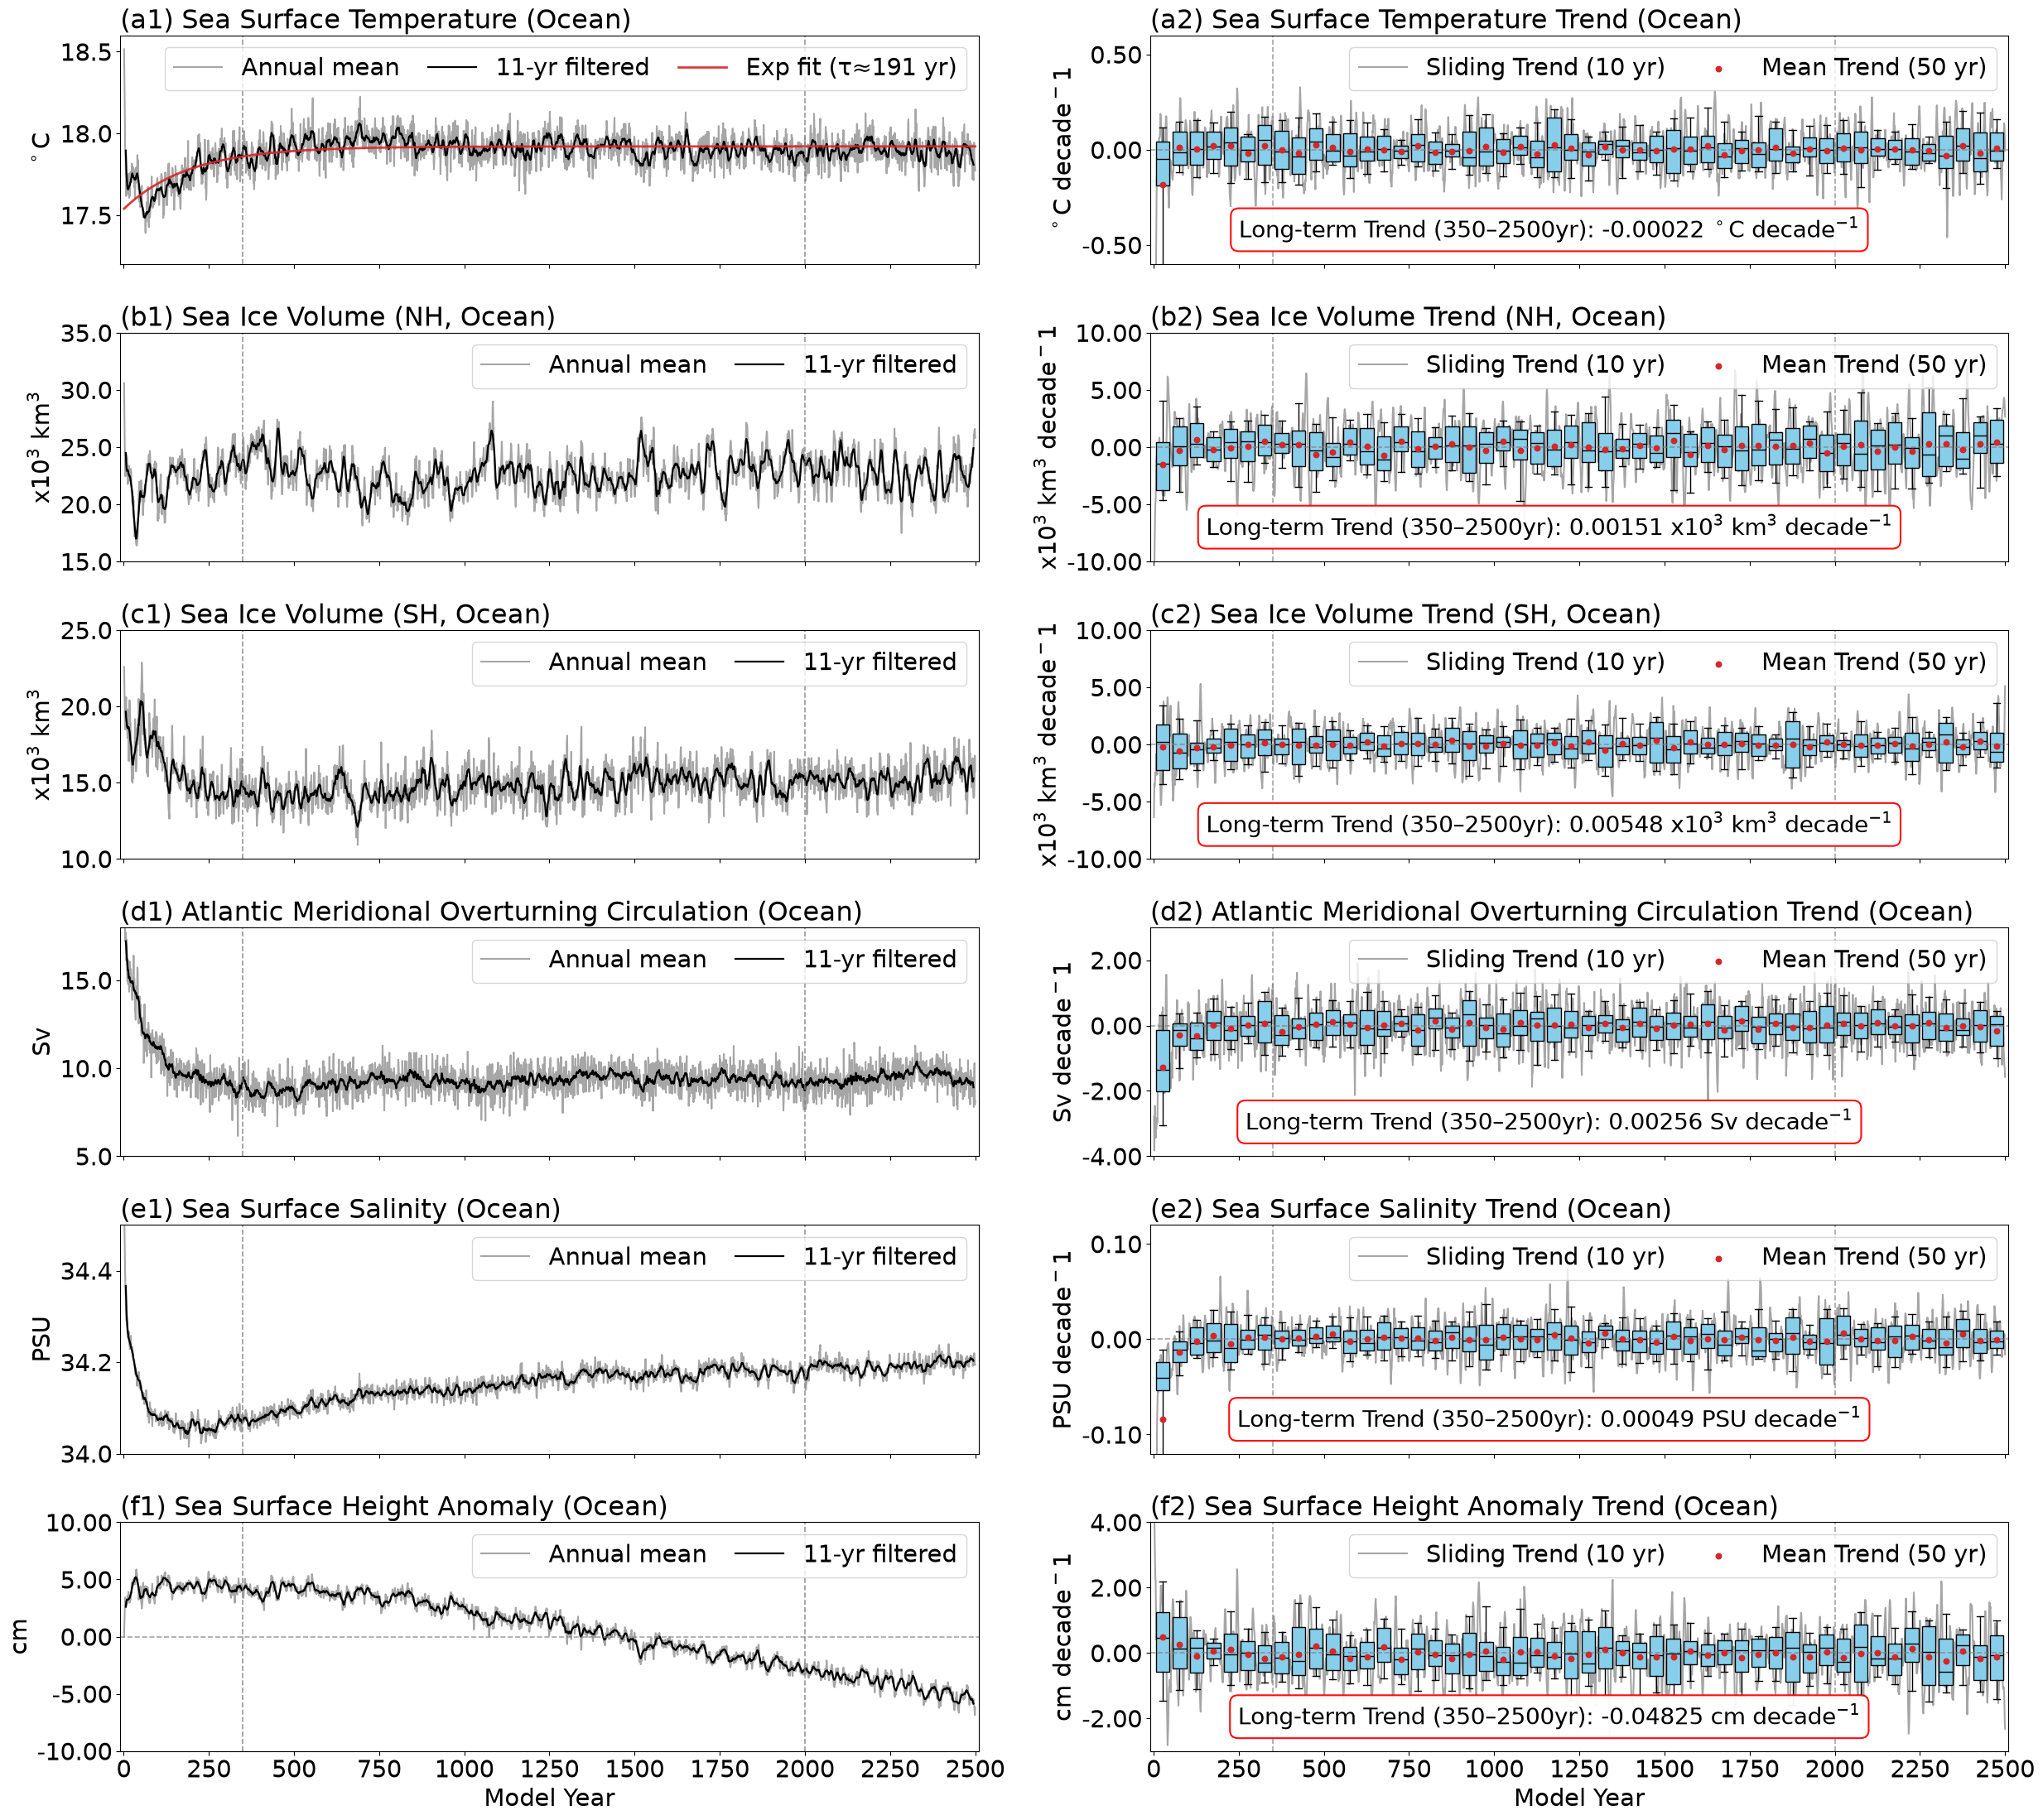

[PLOT] Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts/Full-CPL_OCN_all_annual_0-2500.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ocn_ts


In [17]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# === Experiment & plot span ===
experiment    = EXPERIMENT
plot_syear    = CTRL_YEARS[0]
plot_eyear    = CTRL_YEARS[1]
spinup_period = SPINUP_MARKERS      # vertical markers
suffix        = "annual"
rgn_label     = "Ocean"

# === Variable (SST) ===
var_dict = {
    "SST": {
        "name"  : "timeMonthly_avg_avgValueWithinOceanRegion_avgSurfaceTemperature",
        "label" : "Sea Surface Temperature",
        "rgn_label": "Ocean",
        "unit"  : r"$^\circ$C",
        "key"   : "mpasTimeSeriesOcean",
        "decay" : True,
        "min"   : 17.2,
        "max"   : 18.6,
        "dmin"  : -0.6,
        "dmax"  :  0.6,
    },
    "iceVolumeNH": {
        "name":  "iceVolume",
        "label": "Sea Ice Volume",
        "rgn_label": "NH, Ocean",
        "unit":  r"x10$^3$ km$^3$",
        "key":   "seaIceAreaVolNH",
        "decay" : False,
        "min"   :  15.0,
        "max"   :  35.0,
        "dmin"  : -10,
        "dmax"  :  10,
    },
    "iceVolumeSH": {
        "name":  "iceVolume",
        "label": "Sea Ice Volume",
        "rgn_label": "SH, Ocean",
        "unit":  r"x10$^3$ km$^3$",
        "key":   "seaIceAreaVolSH",
        "decay" : False,
        "min"   :  10.0,
        "max"   :  25.0,
        "dmin"  : -10,
        "dmax"  :  10,
    },
    "AMOC": {
        "name":  "mocAtlantic26",
        "label": "Atlantic Meridional Overturning Circulation",
        "rgn_label": "Ocean",
        "unit":  r"Sv",
        "key":   "mocTimeSeries",
        "decay" : False,
        "min"   :  5.0,
        "max"   :  18.0,
        "dmin"  : -4,
        "dmax"  :  3,
    },
    "SSS": {
        "name"  : "timeMonthly_avg_avgValueWithinOceanLayerRegion_avgLayerSalinity",
        "label" : "Sea Surface Salinity",
        "rgn_label": "Ocean",
        "unit"  : r"PSU",
        "key"   : "mpasTimeSeriesOcean",
        "decay" : False,
        "min"   : 34.0,
        "max"   : 34.5,
        "dmin"  : -0.12,
        "dmax"  :  0.12,
    },
    "SSH": {
        "name"  : "SSH",
        "label" : "Sea Surface Height Anomaly",
        "rgn_label": "Ocean",
        "unit"  : "cm",
        "key"   : "mpasTimeSeriesOcean",
        "decay" : False,
        "min"   : -10.0,
        "max"   :  10.0,
        "dmin"  : -3,
        "dmax"  :  4,
    },
}

window = 10            # sliding-trend window to display
box_window = 50
filter_window = 11
nxlab = 250
show_filter = True
legend_one_row=True
decay_fit_range=(plot_syear, spinup_period[1])
decay_tail_years=200
fig_id = 0

plot_combined = True

if plot_combined: 
    figsize = (24,28)
    fontz = 22
    nrows = 1
    ncols = 2
    do_save=False
    do_show=False
    do_close=False
    nrows = len(var_dict)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex="col")
else:
    figsize = (24,4)
    fontz = 18
    nrows = 1
    ncols = 1
    do_save=True
    do_show=True
    do_close=True
    fig=None
    axes=None

# Trend range box 
show_trend_range_box = True 
trend_mode = "full_period",
trend_fit_range = (spinup_period[0],plot_eyear)        # e.g., (syear, eyear) or (spinup_markers[0], eyear)
use_filtered_for_trend = True  # use yf if available
trend_text_position_dict = {
    meta['name']: {'x': 0.02, 'y': 0.98}
    for meta in var_dict.values()
}
# Override specific variables with custom positions
trend_text_position_dict.update({
    'SST':   {'x': 0.465, 'y': 0.15},
    'SSS':   {'x': 0.465, 'y': 0.15},
    'SSH':   {'x': 0.465, 'y': 0.15},
    'AMOC':  {'x': 0.465, 'y': 0.15},
    'iceVolumeNH':  {'x': 0.465, 'y': 0.15},
    'iceVolumeSH':  {'x': 0.465, 'y': 0.15},
}) 

for i, var_name in enumerate(var_dict.keys()):

    fid = fig_id + i
    trend_x = trend_text_position_dict[var_name]['x']
    trend_y = trend_text_position_dict[var_name]['y']

    # === Tidy file produced by MPASDiagnosticsBuilder ===
    combined_tidy = os.path.join(
        out_dir, f"{var_name}_{experiment}_combined_{var_dict[var_name]['name']}_{suffix}_{plot_syear}-{plot_eyear}.nc"
    )
    if not os.path.isfile(combined_tidy):
        raise FileNotFoundError(f"Missing tidy file: {combined_tidy}")

    out_pdf_name = f"{experiment}_{var_name}_{suffix}_{plot_syear}-{plot_eyear}.pdf"

    # === Plot ===
    plotter = OceanDriftPlotter(
        data_var=var_dict[var_name]['name'],
        var_name=var_name,
        var_label=var_dict[var_name]['label'],
        var_unit=var_dict[var_name]['unit']
    )

    plotter.plot_from_tidy(
        tidy_nc=combined_tidy,
        out_pdf=out_pdf_name,          # saved inside fig_dir
        fig_dir=fig_dir,
        experiment=experiment,
        window=window,                     # sliding-trend window shown
        box_window=box_window,
        filter_window=filter_window,
        syear=plot_syear,
        eyear=plot_eyear,
        show_filter=show_filter,
        nxlab=nxlab,
        spinup_markers=spinup_period,
        fig=fig,
        axes=axes,
        nrows=nrows,
        ncols=ncols,
        row_idx=i,
        fig_id=fid,
        fontz=fontz,
        figsize=figsize,
        do_save=do_save,
        do_show=do_show,
        do_close=do_close,
        ymin=var_dict[var_name]['min'],
        ymax=var_dict[var_name]['max'],
        dmin=var_dict[var_name]['dmin'],
        dmax=var_dict[var_name]['dmax'],
        rgn_label=var_dict[var_name]['rgn_label'],
        show_decay=var_dict[var_name]['decay'],
        decay_fit_range=decay_fit_range,
        decay_tail_years=decay_tail_years,
        legend_one_row=legend_one_row,
        data_out_dir=DATA_DIR,          # CSV cache
        show_trend_range_box=show_trend_range_box,
        trend_mode=trend_mode,
        trend_fit_range=trend_fit_range,
        use_filtered_for_trend=use_filtered_for_trend,
        trend_x=trend_x,
        trend_y=trend_y,
    )

    print("[INFO] SST plot generated:", os.path.join(fig_dir, out_pdf_name))

if plot_combined: 
    # save a combined panel for all variables 
    final_out = os.path.join(fig_dir, f"{experiment}_OCN_all_{suffix}_{plot_syear}-{plot_eyear}.pdf")
    fig.subplots_adjust(hspace=0.30, wspace=0.20)
    fig.savefig(final_out, bbox_inches="tight", dpi=600)
    plt.show()
    plt.close(fig)
    print("[PLOT] Saved:", final_out)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
